In [33]:
from pathlib import Path
import json
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_FILE = Path("nfhs_full5-30.csv")
GEO_FILE = Path("data/india_states.geojson")
META_FILE = Path("data/meta.json")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Publication defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df_nfhs = pd.read_csv(DATA_FILE)
with open(META_FILE) as f:
    meta = json.load(f)

ROUND_YEARS = meta["round_years"]
WAVE_MAP = {"NFHS-3": 3, "NFHS-4": 4, "NFHS-5": 5, "NFHS-6": 6}
YEAR_MID = {"NFHS-3": 2005.5, "NFHS-4": 2015.5, "NFHS-5": 2020.0, "NFHS-6": 2023.5}

df_nfhs.head()

,state,round,year,area,section,indicator,harmonized_indicator,value,data_flag,source
0,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 5 years (%),NaN,6.6,NaN,NFHS-6 PDF
1,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 5 years (%),NaN,8.6,NaN,NFHS-6 PDF
2,India,NFHS-6,2023-24,Total,Population and Household Profile,Population below age 5 years (%),NaN,8.0,NaN,NFHS-6 PDF
3,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),22.0,NaN,NFHS-6 PDF
4,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),27.0,NaN,NFHS-6 PDF


In [34]:
# Keywords
FERTILITY_KW   = ["fertility rate", "tfr", "total fertility",
                        "birth rate", "children born", "births per"]
PHONE_KW       = ["mobile phone", "mobile telephone", "cell phone",
                        "smartphone", "phone ownership", "use mobile"]
INTERNET_KW    = ["internet", "online"]
EDUCATION_KW   = ["literate", "literacy", "education", "schooling",
                        "no education", "secondary", "years of school"]
WEALTH_KW      = ["wealth", "poorest", "richest", "quintile",
                        "household assets", "below poverty"]
URBAN_KW       = ["urban", "rural"]
CONTRACEPTION_KW     = ["contracepti", "family planning", "modern method",
                        "unmet need", "steriliz"]
EMPOWERMENT_KW       = ["decision", "autonomy", "empowerment",
                        "own money", "bank account", "financial"]

# Harmonised indicator crosswalk (Pakhare & Joshi)
HARMONISED = {
    "tfr": "Total fertility rate (children per woman)",
    "mobile": "Women with own mobile phone (%)",
    "internet": "Women who ever used the internet (%)",
    "literacy": "Women (15-49) who are literate (%)",
    "schooling": "Women (15-49) with 10+ years schooling (%)",
    "fp_modern": "FP: Any modern method (%)",
    "unmet_fp": "Total unmet need for FP (%)",
    "empowerment": "Married women participate in HH decisions (%)",
    "electricity": "Households with electricity (%)",
    "bank": "Women with own bank/savings account (%)",
}

MAIN_ROUNDS = ["NFHS-4", "NFHS-5", "NFHS-6"]
INTERNET_ROUNDS = ["NFHS-5", "NFHS-6"]
REG_CONTROLS = ["schooling", "fp_modern", "electricity"]  # literacy absent in NFHS-6

EXCLUDE_STATES = {"India"}
# Legacy UTs split in NFHS-3/4; merged from NFHS-5 onward
LEGACY_UTS = {"Dadra and Nagar Haveli", "Daman and Diu"}

In [35]:


def build_panel(df, rounds, indicators=None, area="Total", require_vars=None):
    """Wide state × round panel from harmonised indicators."""
    indicators = indicators or HARMONISED
    inv = {v: k for k, v in indicators.items()}
    require_vars = require_vars if require_vars is not None else ["tfr", "mobile"]

    sub = df[
        (df["area"] == area)
        & (~df["state"].isin(EXCLUDE_STATES))
        & (df["round"].isin(rounds))
        & (df["harmonized_indicator"].isin(indicators.values()))
    ].copy()
    sub = sub[~sub["data_flag"].astype(str).str.contains("Parenthesised", na=False)]

    wide = (
        sub.pivot_table(
            index=["state", "round"],
            columns="harmonized_indicator",
            values="value",
            aggfunc="first",
        )
        .rename(columns=inv)
        .reset_index()
    )
    wide["wave"] = wide["round"].map(WAVE_MAP)
    wide["year_mid"] = wide["round"].map(YEAR_MID)
    wide["year_label"] = wide["round"].map(ROUND_YEARS)

    req_cols = require_vars if require_vars else None
    complete = wide.dropna(subset=req_cols) if req_cols else wide.copy()
    return wide, complete


panel_all, panel_main = build_panel(
    df_nfhs, MAIN_ROUNDS, require_vars=["tfr", "mobile"]
)
panel_reg = panel_main.dropna(subset=["tfr", "mobile"] + REG_CONTROLS)

panel_main.to_csv(OUTPUT_DIR / "panel_state_total.csv", index=False)
print(f"Main panel: {len(panel_main)} obs, {panel_main['state'].nunique()} states")
print(f"Regression sample: {len(panel_reg)} obs, {panel_reg['state'].nunique()} states")
panel_main.head()

Main panel: 107 obs, 38 states
Regression sample: 107 obs, 38 states


harmonized_indicator,state,round,fp_modern,electricity,empowerment,tfr,unmet_fp,literacy,schooling,internet,bank,mobile,wave,year_mid,year_label
0,Andaman and Nicobar Islands,NFHS-4,48.30,97.00,92.60,1.50,15.50,84.10,49.10,NaN,81.80,66.90,4,2015.5,2015-16
1,Andaman and Nicobar Islands,NFHS-5,57.73,97.58,94.48,1.28,13.51,85.97,52.47,34.79,89.21,80.83,5,2020.0,2019-21
2,Andaman and Nicobar Islands,NFHS-6,66.30,97.50,94.80,0.90,4.60,NaN,65.00,72.00,93.30,86.70,6,2023.5,2023-24
3,Andhra Pradesh,NFHS-4,69.40,98.80,79.90,1.80,4.70,62.90,34.30,NaN,66.30,36.20,4,2015.5,2015-16
4,Andhra Pradesh,NFHS-5,70.84,99.45,84.05,1.68,4.68,68.64,39.63,20.97,81.78,48.94,5,2020.0,2019-21


In [36]:
# --- Indicator audit: coverage matrix & keyword search ---

def coverage_matrix(df, var, rounds):
    tmp = df[df["round"].isin(rounds)].copy()
    tmp["has_val"] = tmp[var].notna().astype(int)
    return tmp.pivot_table(index="state", columns="round", values="has_val", aggfunc="max", fill_value=0)


print("=" * 60)
print("COVERAGE: TFR and Mobile (Total area, excl. India)")
print("=" * 60)
for label, var in [("TFR", "tfr"), ("Mobile", "mobile")]:
    mat = coverage_matrix(panel_all, var, MAIN_ROUNDS)
    print(f"\n{label} — states with data by round:")
    print(mat.sum(axis=0))
    missing = mat[(mat.sum(axis=1) < len(MAIN_ROUNDS))].index.tolist()
    if missing:
        print(f"  Incomplete states ({len(missing)}): {missing}")

lit_cov = coverage_matrix(panel_all, "literacy", MAIN_ROUNDS)
print(f"\nLiteracy NFHS-6 coverage: {lit_cov['NFHS-6'].sum()} states (0 expected — not harmonised in NFHS-6)")

print("\n" + "=" * 60)
print("ATTRITION")
print("=" * 60)
for desc, n in [
    ("All state-rounds (NFHS-4/5/6)", len(panel_all)),
    ("Non-missing TFR + mobile", len(panel_main)),
    ("+ non-missing controls", len(panel_reg)),
]:
    print(f"  {desc}: {n}")

def kw_match(text, keywords):
    t = str(text).lower()
    return any(k in t for k in keywords)

unmapped_phone = df_nfhs[
    (df_nfhs["area"] == "Total")
    & (~df_nfhs["state"].isin(EXCLUDE_STATES))
    & (df_nfhs["round"].isin(MAIN_ROUNDS))
    & (df_nfhs["harmonized_indicator"].isna() | (df_nfhs["harmonized_indicator"] == ""))
    & df_nfhs["indicator"].apply(lambda x: kw_match(x, PHONE_KW))
]["indicator"].unique()

print("\nUnmapped raw indicators matching PHONE_KW:")
print(unmapped_phone if len(unmapped_phone) else "  None — all phone measures are harmonised.")

COVERAGE: TFR and Mobile (Total area, excl. India)

TFR — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Mobile — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Literacy NFHS-6 coverage: 0 states (0 expected — not harmonised in NFHS-6)

ATTRITION
  All state-rounds (NFHS-4/5/6): 107
  Non-missing TFR + mobile: 107
  + non-missing controls: 107

Unmapped raw indicators matching PHONE_KW:
  None — all phone measures are harmonised.


In [37]:
# --- Figure helpers: state labels, pairwise deltas, save ---

FIG_HARMONISED = {
    **HARMONISED,
    "srb": "Sex ratio at birth, last 5 years (f per 1000 males)",
}

TRANSITIONS = [
    ("NFHS-3", "NFHS-4"),
    ("NFHS-4", "NFHS-5"),
    ("NFHS-5", "NFHS-6"),
]
TRANSITION_LABELS = {
    ("NFHS-3", "NFHS-4"): "NFHS-3→4",
    ("NFHS-4", "NFHS-5"): "NFHS-4→5 (Jio)",
    ("NFHS-5", "NFHS-6"): "NFHS-5→6",
}
JIO_TRANSITION = ("NFHS-4", "NFHS-5")


def report_drops(all_states, used_states, label):
    """Print state count and list of dropped states."""
    dropped = sorted(set(all_states) - set(used_states))
    print(f"{label}: N={len(used_states)}")
    if dropped:
        print(f"  Dropped ({len(dropped)}): {', '.join(dropped)}")
    return dropped


def pairwise_delta(df, var, round_from, round_to):
    """State-level first difference between two NFHS rounds."""
    a = df[df["round"] == round_from][["state", var]].rename(columns={var: "v_from"})
    b = df[df["round"] == round_to][["state", var]].rename(columns={var: "v_to"})
    merged = a.merge(b, on="state", how="outer")
    merged["delta"] = merged["v_to"] - merged["v_from"]
    merged["transition"] = TRANSITION_LABELS.get(
        (round_from, round_to), f"{round_from}→{round_to}"
    )
    complete = merged.dropna(subset=["v_from", "v_to"]).copy()
    return complete


def save_figure(fig, stem):
    """Save figure as PNG to OUTPUT_DIR."""
    fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")


panel_full, _ = build_panel(
    df_nfhs, meta["rounds"], indicators=FIG_HARMONISED, require_vars=[]
)
print(f"Full panel (NFHS-3–6): {len(panel_full)} obs, {panel_full['state'].nunique()} states")

Full panel (NFHS-3–6): 135 obs, 38 states


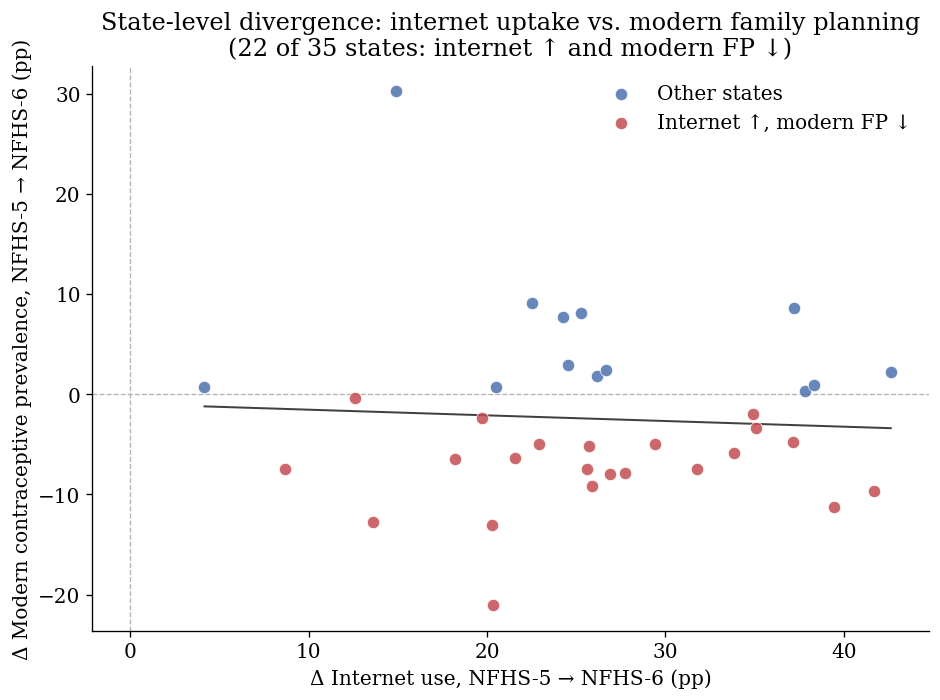

In [38]:
# --- Figure 6: NFHS-5 → NFHS-6 internet vs modern FP divergence ---

panel_56 = panel_all[panel_all["round"].isin(["NFHS-5", "NFHS-6"])].copy()

d_internet = pairwise_delta(panel_56, "internet", "NFHS-5", "NFHS-6")
d_fp = pairwise_delta(panel_56, "fp_modern", "NFHS-5", "NFHS-6")

fig6 = d_internet[["state", "delta"]].merge(
    d_fp[["state", "delta"]], on="state", suffixes=("_internet", "_fp")
).rename(columns={"delta_fp": "delta_fp_modern"})

fig6["puzzle"] = (fig6["delta_internet"] > 0) & (fig6["delta_fp_modern"] < 0)
n_puzzle = fig6["puzzle"].sum()

COLOR_OTHER = "#4C72B0"
COLOR_PUZZLE = "#C44E52"

fig, ax = plt.subplots(figsize=(8, 6))
for puzzle, color, label in [
    (False, COLOR_OTHER, "Other states"),
    (True, COLOR_PUZZLE, "Internet ↑, modern FP ↓"),
]:
    sub = fig6[fig6["puzzle"] == puzzle]
    ax.scatter(
        sub["delta_internet"],
        sub["delta_fp_modern"],
        c=color,
        s=55,
        alpha=0.85,
        label=label,
        edgecolors="white",
        linewidths=0.5,
        zorder=3,
    )

sns.regplot(
    data=fig6,
    x="delta_internet",
    y="delta_fp_modern",
    scatter=False,
    color="0.25",
    line_kws={"linewidth": 1.2},
    ci=None,
    ax=ax,
)

ax.axhline(0, color="0.7", linestyle="--", linewidth=0.8, zorder=1)
ax.axvline(0, color="0.7", linestyle="--", linewidth=0.8, zorder=1)
ax.set_xlabel("Δ Internet use, NFHS-5 → NFHS-6 (pp)")
ax.set_ylabel("Δ Modern contraceptive prevalence, NFHS-5 → NFHS-6 (pp)")
ax.set_title(
    "State-level divergence: internet uptake vs. modern family planning\n"
    f"({n_puzzle} of {len(fig6)} states: internet ↑ and modern FP ↓)"
)
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
save_figure(fig, "fig06_internet_fp_divergence")
plt.show()


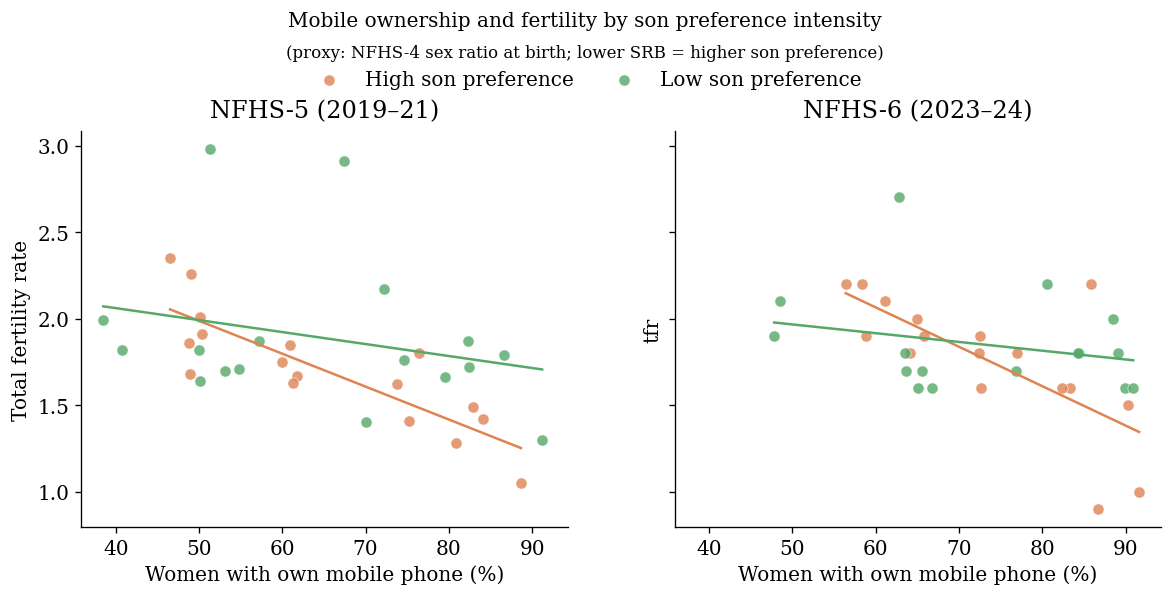

In [39]:
# --- Figure 7: Mobile–TFR heterogeneity by son preference (NFHS-4 SRB proxy) ---
# No direct son-preference measure in panel_main; lower SRB ⇒ stronger son preference.

SRB_INDICATOR = {"srb": "Sex ratio at birth, last 5 years (f per 1000 males)"}
_, panel_srb4 = build_panel(
    df_nfhs, ["NFHS-4"], indicators=SRB_INDICATOR, require_vars=[]
)
srb_baseline = panel_srb4[["state", "srb"]].dropna()
srb_median = srb_baseline["srb"].median()
srb_baseline["son_pref_group"] = np.where(
    srb_baseline["srb"] < srb_median,
    "High son preference",
    "Low son preference",
)

GROUP_COLORS = {
    "High son preference": "#DD8452",
    "Low son preference": "#55A868",
}
GROUP_ORDER = ["High son preference", "Low son preference"]

fig7_data = []
for rnd in ["NFHS-5", "NFHS-6"]:
    cross = panel_main[panel_main["round"] == rnd][["state", "mobile", "tfr"]].dropna()
    cross = cross.merge(srb_baseline[["state", "son_pref_group", "srb"]], on="state", how="inner")
    cross["round"] = rnd
    fig7_data.append(cross)

fig7_df = pd.concat(fig7_data, ignore_index=True)

x_pad = 0.05 * (fig7_df["mobile"].max() - fig7_df["mobile"].min())
y_pad = 0.05 * (fig7_df["tfr"].max() - fig7_df["tfr"].min())
xlim = (fig7_df["mobile"].min() - x_pad, fig7_df["mobile"].max() + x_pad)
ylim = (fig7_df["tfr"].min() - y_pad, fig7_df["tfr"].max() + y_pad)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
round_titles = {"NFHS-5": "NFHS-5 (2019–21)", "NFHS-6": "NFHS-6 (2023–24)"}

for ax, rnd in zip(axes, ["NFHS-5", "NFHS-6"]):
    sub = fig7_df[fig7_df["round"] == rnd]
    for grp in GROUP_ORDER:
        g = sub[sub["son_pref_group"] == grp]
        ax.scatter(
            g["mobile"],
            g["tfr"],
            c=GROUP_COLORS[grp],
            s=45,
            alpha=0.8,
            label=grp,
            edgecolors="white",
            linewidths=0.4,
        )
        if len(g) >= 2:
            sns.regplot(
                data=g,
                x="mobile",
                y="tfr",
                scatter=False,
                color=GROUP_COLORS[grp],
                line_kws={"linewidth": 1.5},
                ci=None,
                ax=ax,
            )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(round_titles[rnd], pad=8)
    ax.set_xlabel("Women with own mobile phone (%)")
    if ax is axes[0]:
        ax.set_ylabel("Total fertility rate")

handles, labels = axes[0].get_legend_handles_labels()
fig.text(
    0.5,
    0.98,
    "Mobile ownership and fertility by son preference intensity",
    ha="center",
    va="top",
    fontsize=12,
)
fig.text(
    0.5,
    0.925,
    "(proxy: NFHS-4 sex ratio at birth; lower SRB = higher son preference)",
    ha="center",
    va="top",
    fontsize=10,
)
fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.5, 0.865),
    ncol=2,
    frameon=False,
    columnspacing=1.5,
    borderaxespad=0,
)
fig.subplots_adjust(top=0.78, bottom=0.12, wspace=0.22, left=0.08, right=0.98)

save_figure(fig, "fig07_mobile_tfr_sonpref")
plt.show()


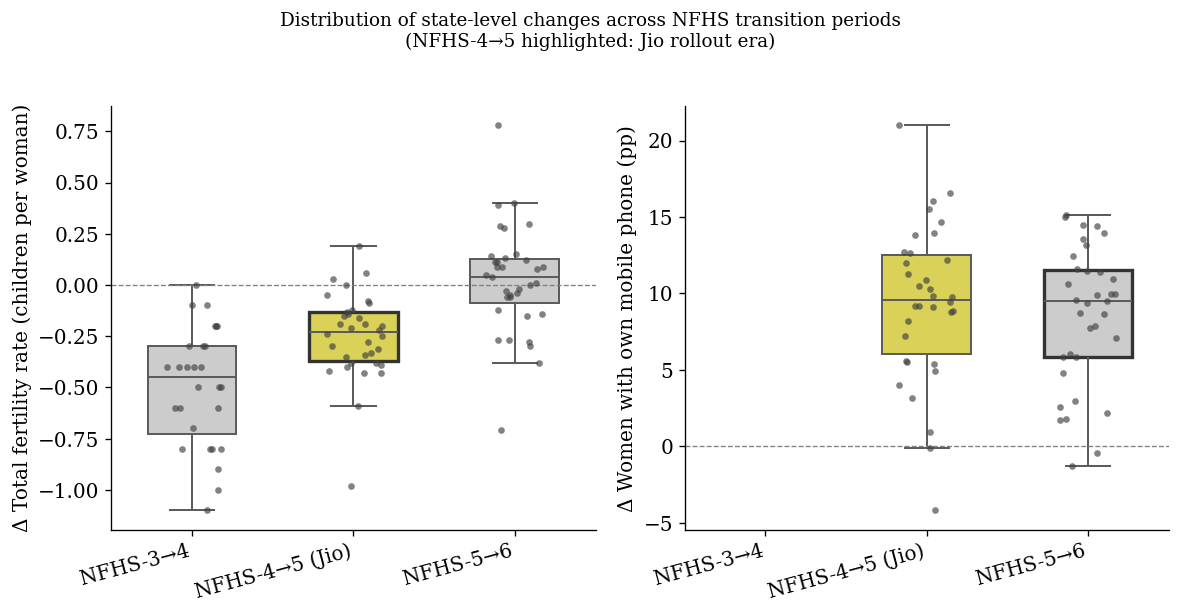

In [40]:
# --- Figure 8: Boxplots of TFR and mobile changes by transition period ---

delta_rows = []
for r_from, r_to in TRANSITIONS:
    label = TRANSITION_LABELS[(r_from, r_to)]
    for var in ["tfr", "mobile"]:
        d = pairwise_delta(panel_full, var, r_from, r_to)
        for _, row in d.iterrows():
            delta_rows.append(
                {
                    "state": row["state"],
                    "transition": label,
                    "variable": var,
                    "delta": row["delta"],
                    "is_jio": (r_from, r_to) == JIO_TRANSITION,
                }
            )

delta_long = pd.DataFrame(delta_rows)
transition_order = [TRANSITION_LABELS[t] for t in TRANSITIONS]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
var_specs = [
    ("tfr", "Δ Total fertility rate (children per woman)"),
    ("mobile", "Δ Women with own mobile phone (pp)"),
]

for ax, (var, ylab) in zip(axes, var_specs):
    sub = delta_long[delta_long["variable"] == var]
    palette = {
        lbl: "#F0E442" if lbl == TRANSITION_LABELS[JIO_TRANSITION] else "#CCCCCC"
        for lbl in transition_order
    }
    sns.boxplot(
        data=sub,
        x="transition",
        y="delta",
        order=transition_order,
        palette=palette,
        width=0.55,
        fliersize=0,
        ax=ax,
        linewidth=1.2,
    )
    jio_idx = transition_order.index(TRANSITION_LABELS[JIO_TRANSITION])
    if jio_idx < len(ax.patches):
        ax.patches[jio_idx].set_edgecolor("#333333")
        ax.patches[jio_idx].set_linewidth(2.0)

    sns.stripplot(
        data=sub,
        x="transition",
        y="delta",
        order=transition_order,
        color="0.25",
        alpha=0.65,
        size=4,
        jitter=0.18,
        ax=ax,
        zorder=3,
    )
    ax.axhline(0, color="0.5", linestyle="--", linewidth=0.8)
    ax.set_xlabel("")
    ax.set_ylabel(ylab)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(15)
        lbl.set_ha("right")

fig.suptitle(
    "Distribution of state-level changes across NFHS transition periods\n"
    "(NFHS-4→5 highlighted: Jio rollout era)",
    y=1.02,
    fontsize=11,
)
fig.tight_layout()
save_figure(fig, "fig08_transition_boxplots")
plt.show()


In [41]:
from pathlib import Path
import json
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_FILE = Path("nfhs_full5-30.csv")
GEO_FILE = Path("data/india_states.geojson")
META_FILE = Path("data/meta.json")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Publication defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df_nfhs = pd.read_csv(DATA_FILE)
with open(META_FILE) as f:
    meta = json.load(f)

ROUND_YEARS = meta["round_years"]
WAVE_MAP = {"NFHS-3": 3, "NFHS-4": 4, "NFHS-5": 5, "NFHS-6": 6}
YEAR_MID = {"NFHS-3": 2005.5, "NFHS-4": 2015.5, "NFHS-5": 2020.0, "NFHS-6": 2023.5}

df_nfhs.head()

,state,round,year,area,section,indicator,harmonized_indicator,value,data_flag,source
0,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 5 years (%),NaN,6.6,NaN,NFHS-6 PDF
1,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 5 years (%),NaN,8.6,NaN,NFHS-6 PDF
2,India,NFHS-6,2023-24,Total,Population and Household Profile,Population below age 5 years (%),NaN,8.0,NaN,NFHS-6 PDF
3,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),22.0,NaN,NFHS-6 PDF
4,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),27.0,NaN,NFHS-6 PDF


In [42]:
# Keywords
FERTILITY_KW   = ["fertility rate", "tfr", "total fertility",
                        "birth rate", "children born", "births per"]
PHONE_KW       = ["mobile phone", "mobile telephone", "cell phone",
                        "smartphone", "phone ownership", "use mobile"]
INTERNET_KW    = ["internet", "online"]
EDUCATION_KW   = ["literate", "literacy", "education", "schooling",
                        "no education", "secondary", "years of school"]
WEALTH_KW      = ["wealth", "poorest", "richest", "quintile",
                        "household assets", "below poverty"]
URBAN_KW       = ["urban", "rural"]
CONTRACEPTION_KW     = ["contracepti", "family planning", "modern method",
                        "unmet need", "steriliz"]
EMPOWERMENT_KW       = ["decision", "autonomy", "empowerment",
                        "own money", "bank account", "financial"]

# Harmonised indicator crosswalk (Pakhare & Joshi)
HARMONISED = {
    "tfr": "Total fertility rate (children per woman)",
    "mobile": "Women with own mobile phone (%)",
    "internet": "Women who ever used the internet (%)",
    "literacy": "Women (15-49) who are literate (%)",
    "schooling": "Women (15-49) with 10+ years schooling (%)",
    "fp_modern": "FP: Any modern method (%)",
    "unmet_fp": "Total unmet need for FP (%)",
    "empowerment": "Married women participate in HH decisions (%)",
    "electricity": "Households with electricity (%)",
    "bank": "Women with own bank/savings account (%)",
}

MAIN_ROUNDS = ["NFHS-4", "NFHS-5", "NFHS-6"]
INTERNET_ROUNDS = ["NFHS-5", "NFHS-6"]
REG_CONTROLS = ["schooling", "fp_modern", "electricity"]  # literacy absent in NFHS-6

EXCLUDE_STATES = {"India"}
# Legacy UTs split in NFHS-3/4; merged from NFHS-5 onward
LEGACY_UTS = {"Dadra and Nagar Haveli", "Daman and Diu"}

In [43]:


def build_panel(df, rounds, indicators=None, area="Total", require_vars=None):
    """Wide state × round panel from harmonised indicators."""
    indicators = indicators or HARMONISED
    inv = {v: k for k, v in indicators.items()}
    require_vars = require_vars or ["tfr", "mobile"]

    sub = df[
        (df["area"] == area)
        & (~df["state"].isin(EXCLUDE_STATES))
        & (df["round"].isin(rounds))
        & (df["harmonized_indicator"].isin(indicators.values()))
    ].copy()
    sub = sub[~sub["data_flag"].astype(str).str.contains("Parenthesised", na=False)]

    wide = (
        sub.pivot_table(
            index=["state", "round"],
            columns="harmonized_indicator",
            values="value",
            aggfunc="first",
        )
        .rename(columns=inv)
        .reset_index()
    )
    wide["wave"] = wide["round"].map(WAVE_MAP)
    wide["year_mid"] = wide["round"].map(YEAR_MID)
    wide["year_label"] = wide["round"].map(ROUND_YEARS)

    req_cols = require_vars
    complete = wide.dropna(subset=req_cols)
    return wide, complete


panel_all, panel_main = build_panel(
    df_nfhs, MAIN_ROUNDS, require_vars=["tfr", "mobile"]
)
panel_reg = panel_main.dropna(subset=["tfr", "mobile"] + REG_CONTROLS)

panel_main.to_csv(OUTPUT_DIR / "panel_state_total.csv", index=False)
print(f"Main panel: {len(panel_main)} obs, {panel_main['state'].nunique()} states")
print(f"Regression sample: {len(panel_reg)} obs, {panel_reg['state'].nunique()} states")
panel_main.head()

Main panel: 107 obs, 38 states
Regression sample: 107 obs, 38 states


harmonized_indicator,state,round,fp_modern,electricity,empowerment,tfr,unmet_fp,literacy,schooling,internet,bank,mobile,wave,year_mid,year_label
0,Andaman and Nicobar Islands,NFHS-4,48.30,97.00,92.60,1.50,15.50,84.10,49.10,NaN,81.80,66.90,4,2015.5,2015-16
1,Andaman and Nicobar Islands,NFHS-5,57.73,97.58,94.48,1.28,13.51,85.97,52.47,34.79,89.21,80.83,5,2020.0,2019-21
2,Andaman and Nicobar Islands,NFHS-6,66.30,97.50,94.80,0.90,4.60,NaN,65.00,72.00,93.30,86.70,6,2023.5,2023-24
3,Andhra Pradesh,NFHS-4,69.40,98.80,79.90,1.80,4.70,62.90,34.30,NaN,66.30,36.20,4,2015.5,2015-16
4,Andhra Pradesh,NFHS-5,70.84,99.45,84.05,1.68,4.68,68.64,39.63,20.97,81.78,48.94,5,2020.0,2019-21


In [44]:
# --- Indicator audit: coverage matrix & keyword search ---

def coverage_matrix(df, var, rounds):
    tmp = df[df["round"].isin(rounds)].copy()
    tmp["has_val"] = tmp[var].notna().astype(int)
    return tmp.pivot_table(index="state", columns="round", values="has_val", aggfunc="max", fill_value=0)


print("=" * 60)
print("COVERAGE: TFR and Mobile (Total area, excl. India)")
print("=" * 60)
for label, var in [("TFR", "tfr"), ("Mobile", "mobile")]:
    mat = coverage_matrix(panel_all, var, MAIN_ROUNDS)
    print(f"\n{label} — states with data by round:")
    print(mat.sum(axis=0))
    missing = mat[(mat.sum(axis=1) < len(MAIN_ROUNDS))].index.tolist()
    if missing:
        print(f"  Incomplete states ({len(missing)}): {missing}")

lit_cov = coverage_matrix(panel_all, "literacy", MAIN_ROUNDS)
print(f"\nLiteracy NFHS-6 coverage: {lit_cov['NFHS-6'].sum()} states (0 expected — not harmonised in NFHS-6)")

print("\n" + "=" * 60)
print("ATTRITION")
print("=" * 60)
for desc, n in [
    ("All state-rounds (NFHS-4/5/6)", len(panel_all)),
    ("Non-missing TFR + mobile", len(panel_main)),
    ("+ non-missing controls", len(panel_reg)),
]:
    print(f"  {desc}: {n}")

def kw_match(text, keywords):
    t = str(text).lower()
    return any(k in t for k in keywords)

unmapped_phone = df_nfhs[
    (df_nfhs["area"] == "Total")
    & (~df_nfhs["state"].isin(EXCLUDE_STATES))
    & (df_nfhs["round"].isin(MAIN_ROUNDS))
    & (df_nfhs["harmonized_indicator"].isna() | (df_nfhs["harmonized_indicator"] == ""))
    & df_nfhs["indicator"].apply(lambda x: kw_match(x, PHONE_KW))
]["indicator"].unique()

print("\nUnmapped raw indicators matching PHONE_KW:")
print(unmapped_phone if len(unmapped_phone) else "  None — all phone measures are harmonised.")

COVERAGE: TFR and Mobile (Total area, excl. India)

TFR — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Mobile — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Literacy NFHS-6 coverage: 0 states (0 expected — not harmonised in NFHS-6)

ATTRITION
  All state-rounds (NFHS-4/5/6): 107
  Non-missing TFR + mobile: 107
  + non-missing controls: 107

Unmapped raw indicators matching PHONE_KW:
  None — all phone measures are harmonised.
